<a href="https://colab.research.google.com/github/springboardmentor14065l/Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/blob/Nikhil-yadav/week%203-4/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/energy.csv")
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour
df['Minute'] = df['Timestamp'].dt.minute
df = df.drop(['Date', 'Time'], axis=1)
cols = ['Timestamp'] + [c for c in df.columns if c != 'Timestamp']
df = df[cols]
df.to_csv("energy_data_with_timestamp.csv", index=False)
df.head()

,Timestamp,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size,Year,Month,Day,Hour,Minute
0,2023-12-02 21:12:00,94,Fridge,0.20,-1.0,Fall,2,2023,12,2,21,12
1,2023-08-06 20:11:00,435,Oven,0.23,31.1,Summer,5,2023,8,6,20,11
2,2023-11-21 06:39:00,466,Dishwasher,0.32,21.3,Fall,3,2023,11,21,6,39
3,2023-01-21 21:56:00,496,Heater,3.92,-4.2,Winter,1,2023,1,21,21,56
4,2023-08-26 04:31:00,137,Microwave,0.44,34.5,Summer,5,2023,8,26,4,31


In [20]:
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
else:
    # Create Timestamp from split columns
    df['Timestamp'] = pd.to_datetime(
        df['year'].astype(str) + '-' +
        df['Month'].astype(str) + '-' +
        df['Day'].astype(str) + ' ' +
        df['Hour'].astype(str) + ':' +
        df['Minute'].astype(str),
        errors='coerce'
    )


In [24]:
df = df.sort_values('Timestamp').reset_index(drop=True)


In [25]:
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Weekday'] = df['Timestamp'].dt.weekday
df['Week'] = df['Timestamp'].dt.isocalendar().week.astype(int)
df['Month'] = df['Timestamp'].dt.month


In [26]:
df['Is_Weekend'] = (df['Weekday'] >= 5).astype(int)
df['Is_Peak_Hour'] = ((df['Hour'] >= 18) & (df['Hour'] <= 22)).astype(int)


In [28]:
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)


In [29]:
device_agg = df.groupby('Appliance Type')['Energy Consumption (kWh)'].agg(
    Device_Total_kWh='sum',
    Device_Avg_kWh='mean',
    Device_Max_kWh='max',
    Device_Min_kWh='min',
    Device_Std_kWh='std'
).reset_index()


In [30]:
df = df.merge(device_agg, on='Appliance Type', how='left')


In [31]:
df['Lag_1'] = df['Energy Consumption (kWh)'].shift(1)
df['Lag_2'] = df['Energy Consumption (kWh)'].shift(2)
df['Lag_3'] = df['Energy Consumption (kWh)'].shift(3)


In [32]:
df['MA_3'] = df['Energy Consumption (kWh)'].rolling(window=3).mean()
df['MA_6'] = df['Energy Consumption (kWh)'].rolling(window=6).mean()
df['MA_12'] = df['Energy Consumption (kWh)'].rolling(window=12).mean()


In [33]:
df = df.dropna().reset_index(drop=True)


In [34]:
feature_table = df[[
    # Target
    'Energy Consumption (kWh)',

    # Context Features
    'Outdoor Temperature (°C)',
    'Household Size',

    # Time Features
    'Hour', 'Day', 'Week', 'Month',
    'Is_Weekend', 'Is_Peak_Hour',
    'Hour_sin', 'Hour_cos',
    'Month_sin', 'Month_cos',

    # Device Aggregates
    'Device_Avg_kWh',
    'Device_Max_kWh',
    'Device_Std_kWh',

    # Time-Series Features
    'Lag_1', 'Lag_2', 'Lag_3',
    'MA_3', 'MA_6', 'MA_12'
]]


In [35]:
feature_table.to_csv("final_feature_table.csv", index=False)
print("✅ Feature table saved as final_feature_table.csv")
print(feature_table.head())


✅ Feature table saved as final_feature_table.csv
   Energy Consumption (kWh)  Outdoor Temperature (°C)  Household Size  Hour  \
0                      1.93                      29.9               2     1   
1                      1.46                      36.3               5     1   
2                      1.43                      22.7               3     1   
3                      1.83                      39.0               5     1   
4                      1.98                       5.0               2     1   

   Day  Week  Month  Is_Weekend  Is_Peak_Hour  Hour_sin  ...  Month_cos  \
0    1    52      1           1             0  0.258819  ...   0.866025   
1    1    52      1           1             0  0.258819  ...   0.866025   
2    1    52      1           1             0  0.258819  ...   0.866025   
3    1    52      1           1             0  0.258819  ...   0.866025   
4    1    52      1           1             0  0.258819  ...   0.866025   

   Device_Avg_kWh  Device

In [36]:
#aggregation
device_aggregation = df.groupby('Appliance Type')['Energy Consumption (kWh)'].agg(
    Total_Consumption_kWh='sum',
    Average_Consumption_kWh='mean',
    Max_Consumption_kWh='max',
    Min_Consumption_kWh='min',
    Std_Consumption_kWh='std',
    Usage_Count='count'
).reset_index()


/tmp/ipython-input-3556503617.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Appliance Type', y='Total_Consumption_kWh', data=device_aggregation, palette='viridis')


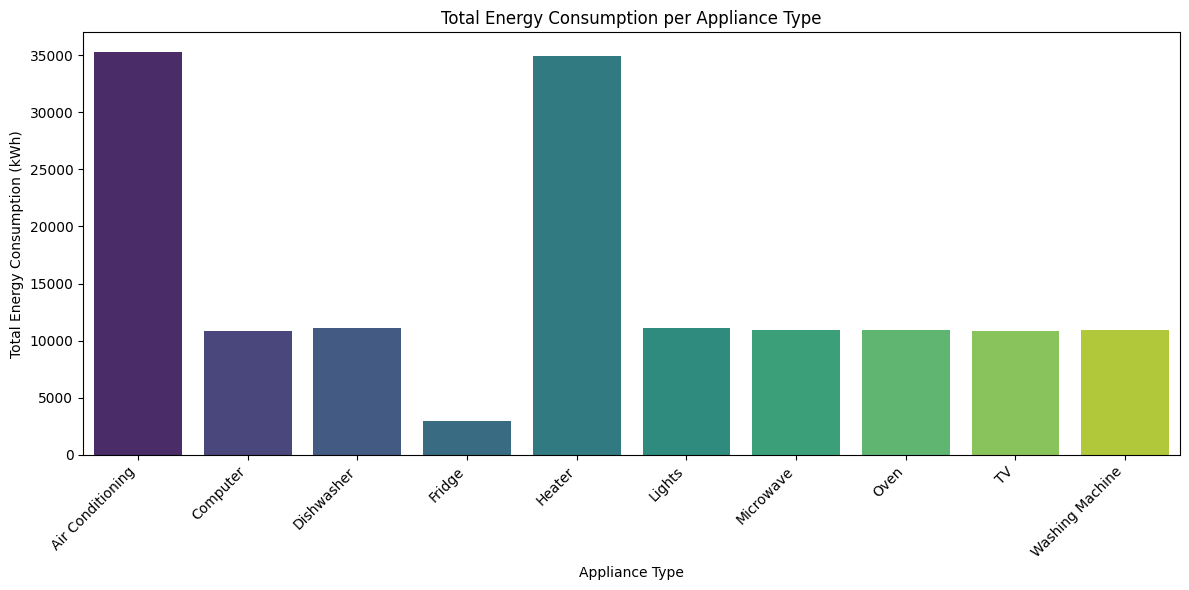

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Appliance Type', y='Total_Consumption_kWh', data=device_aggregation, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Total Energy Consumption per Appliance Type')
plt.xlabel('Appliance Type')
plt.ylabel('Total Energy Consumption (kWh)')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1968953679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_avg.index, y=device_avg.values, palette='mako')


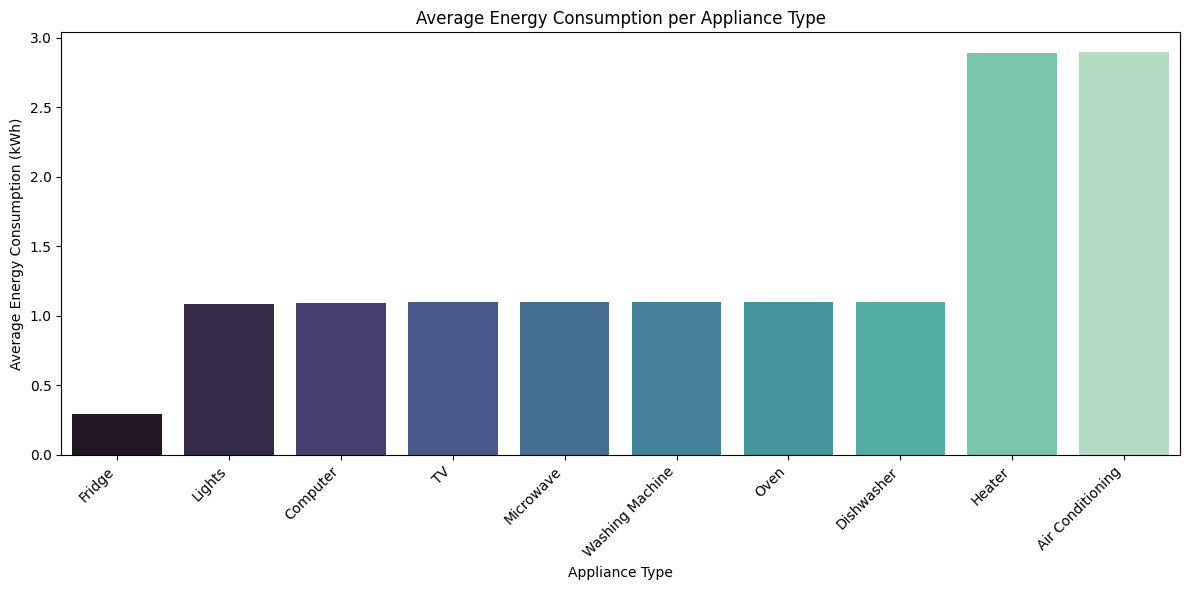

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-plotting the average consumption with consistent style
plt.figure(figsize=(12, 6))
sns.barplot(x=device_avg.index, y=device_avg.values, palette='mako')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption per Appliance Type")
plt.tight_layout()
plt.show()

Next, let's look at the average hourly usage for different appliance types to identify daily patterns.

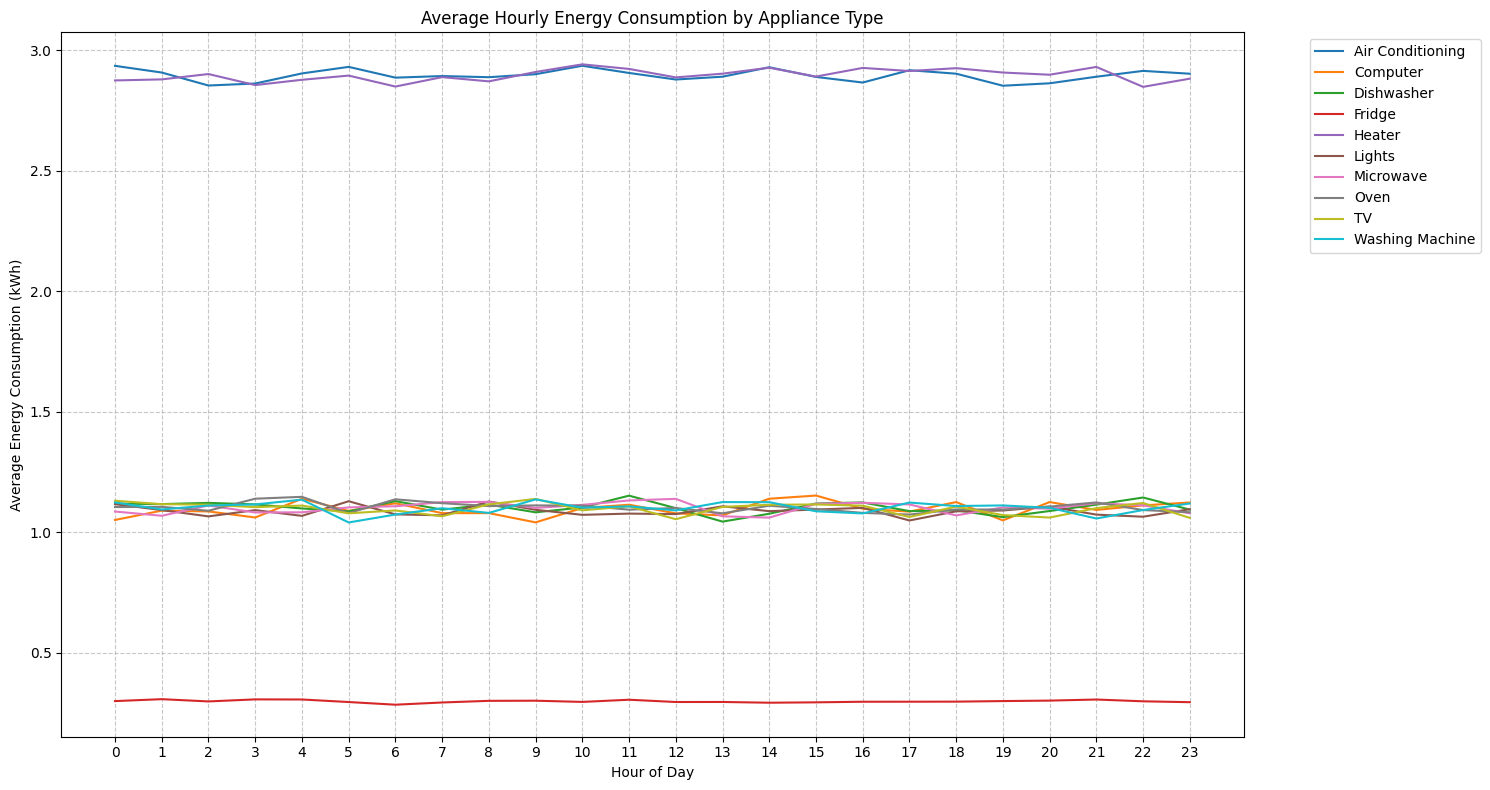

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.lineplot(x='Hour', y='Energy Consumption (kWh)', hue='Appliance Type', data=hourly_device_usage)
plt.title('Average Hourly Energy Consumption by Appliance Type')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (kWh)')
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
print(device_aggregation)


     Appliance Type  Total_Consumption_kWh  Average_Consumption_kWh  \
0  Air Conditioning               17428.50                 2.895581   
1          Computer               10893.63                 1.095498   
2        Dishwasher               11138.51                 1.103369   
3            Fridge                2961.97                 0.298255   
4            Heater               17571.39                 2.895269   
5            Lights               11092.12                 1.087356   
6         Microwave               10951.26                 1.100961   
7              Oven               10963.51                 1.103080   
8                TV               10867.97                 1.097221   
9   Washing Machine               10962.35                 1.101412   

   Max_Consumption_kWh  Min_Consumption_kWh  Std_Consumption_kWh  Usage_Count  
0                 3.79                  2.0             0.516417         6019  
1                 2.00                  0.2             0.

In [11]:
hourly_device_usage = df.groupby(
    ['Appliance Type', 'Hour']
)['Energy Consumption (kWh)'].mean().reset_index()


In [12]:
home_device_usage = df.groupby(
    ['Home ID', 'Appliance Type']
)['Energy Consumption (kWh)'].sum().reset_index()


In [22]:
device_total = df.groupby('Appliance Type')['Energy Consumption (kWh)'].sum().sort_values()


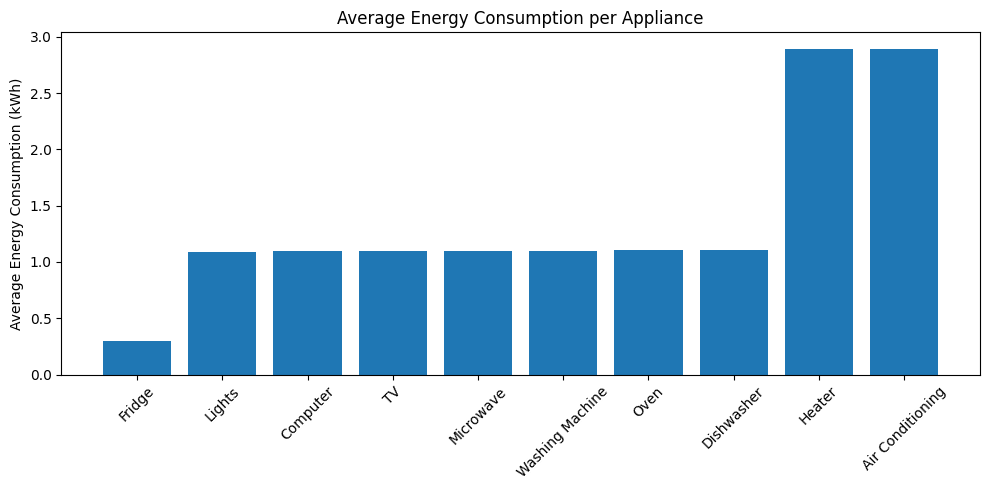

In [14]:
device_avg = df.groupby('Appliance Type')['Energy Consumption (kWh)'].mean().sort_values()
plt.figure(figsize=(10,5))
plt.bar(device_avg.index, device_avg.values)
plt.xticks(rotation=45)
plt.ylabel("Average Energy Consumption (kWh)")
plt.title("Average Energy Consumption per Appliance")
plt.tight_layout()
plt.show()


This initial code block loads the `energy.csv` dataset, processes the date and time columns, creates a `Timestamp` column, extracts year, month, day, hour, and minute, and then saves the processed data to a new CSV file named `energy_data_with_timestamp.csv`. Finally, it displays the first few rows of the DataFrame.

This cell ensures that the 'Timestamp' column in the DataFrame is correctly converted to a datetime object. It checks if 'Timestamp' already exists, and if so, directly converts it. If not, it provides an alternative way to construct it from separate date-time components (though in this notebook, 'Timestamp' is created earlier).

This code sorts the DataFrame `df` by the 'Timestamp' column in ascending order and then resets the index. Sorting by timestamp is crucial for time-series analysis and for correctly calculating lag and moving average features later.

This cell extracts various time-based features from the 'Timestamp' column:
- `Hour`: The hour of the day.
- `Day`: The day of the month.
- `Weekday`: The day of the week (0 for Monday, 6 for Sunday).
- `Week`: The ISO week number of the year.
- `Month`: The month of the year.

These features are important for capturing temporal patterns and seasonality in energy consumption.

This code creates two new binary (0 or 1) features:
- `Is_Weekend`: Indicates if a particular timestamp falls on a weekend (Saturday or Sunday).
- `Is_Peak_Hour`: Indicates if the hour falls within a typical peak energy consumption period (between 6 PM and 10 PM, inclusive).

This cell creates cyclical features for 'Hour' and 'Month' using sine and cosine transformations. This is important for machine learning models as it helps them understand the cyclical nature of time (e.g., that 11 PM is closer to midnight than 1 AM, and December is closer to January than to June).

This code calculates aggregate statistics for 'Energy Consumption (kWh)' grouped by 'Appliance Type'. It computes the total sum, mean, maximum, minimum, and standard deviation of energy consumption for each appliance type. These aggregates provide insights into the consumption patterns of different devices.

This cell merges the `device_agg` DataFrame (containing the aggregated appliance statistics) back into the main `df` DataFrame. This adds the device-level aggregate features to each row, making them available for further analysis or model training.

This code creates lagged features for 'Energy Consumption (kWh)'. Lag features represent past values of a time series, which are often highly predictive of future values. Here, it creates lags for 1, 2, and 3 previous time steps.

This cell calculates moving averages (MA) of 'Energy Consumption (kWh)' over different window sizes (3, 6, and 12 data points). Moving averages help smooth out short-term fluctuations and highlight longer-term trends in the data.

After creating lagged and moving average features, there will inevitably be `NaN` (Not a Number) values at the beginning of the DataFrame. This cell removes all rows containing any `NaN` values, ensuring that only complete data points are used for subsequent steps. It also resets the DataFrame index.

This code creates a `feature_table` DataFrame by selecting specific columns from the main `df`. This table includes the target variable ('Energy Consumption (kWh)') and various features categorized into context features, time features, device aggregates, and time-series features. This curated table is ready for machine learning model training.

This cell saves the final `feature_table` DataFrame to a CSV file named `final_feature_table.csv` without including the DataFrame index. It then prints a confirmation message and displays the first few rows of the saved feature table.

This code calculates various aggregate statistics for 'Energy Consumption (kWh)' grouped by 'Appliance Type'. It computes the total sum, mean, maximum, minimum, standard deviation, and count of usage events for each appliance type. This is stored in `device_aggregation`.

This code generates a bar plot to visualize the `Total_Consumption_kWh` for each `Appliance Type` from the `device_aggregation` DataFrame. It helps to quickly identify which appliance types consume the most total energy.

This code generates a bar plot showing the `Average_Consumption_kWh` for each `Appliance Type` from the `device_avg` Series. It provides insight into the typical energy usage per operation or measurement for different appliances.

This text cell introduces the next visualization, which will focus on average hourly usage for different appliance types to identify daily patterns.

This code generates a line plot visualizing the `Average Hourly Energy Consumption by Appliance Type`. It uses the `hourly_device_usage` DataFrame to show how the average energy consumption of each appliance type changes throughout the 24 hours of a day. This helps identify daily usage peaks and troughs for different devices.

This cell simply prints the `device_aggregation` DataFrame, showing the summarized energy consumption statistics for each appliance type.

This cell calculates the average 'Energy Consumption (kWh)' for each 'Appliance Type' at each `Hour` of the day. This `hourly_device_usage` DataFrame is useful for understanding hourly consumption patterns for different devices.

This cell calculates the total 'Energy Consumption (kWh)' for each 'Appliance Type' within each `Home ID`. This `home_device_usage` DataFrame can be used to analyze appliance usage patterns per household.

This code calculates the total 'Energy Consumption (kWh)' for each 'Appliance Type' and sorts the results in ascending order. This `device_total` Series provides a quick overview of total consumption by device.

This code calculates the average 'Energy Consumption (kWh)' for each 'Appliance Type' and sorts the results. It then creates a bar plot to visually represent this average consumption, making it easy to compare the average energy use across different appliances.